# 중고차 가격 예측 데이터셋(Vehicle dataset)
- 중고차의 여러 특징(연식, 주행거리, 연료 타입, 판매자 유형 등)을 바탕으로 중고차 판매 가격(Selling_Price)을 예측하는 회귀(Regression) 모델 구축을 위한 데이터셋입니다

## 2. 컬럼 상세
| 컬럼명 | 데이터 타입 | 의미 및 설명 |
| :--- | :--- | :--- |
| **Car_Name** | String (Object) | 차량 모델 이름 (예: ritz, sx4, ciaz, wagon r, swift, city, brio 등) |
| **Year** | Integer (int64) | 차량 출고 연도 / 연식 (예: 2014, 2017 등) |
| **Selling_Price (타겟)** | Float (float64) | 중고차 현재 판매 가격 (단위: Lakh - 10만 루피) |
| **Present_Price** | Float (float64) | 차량의 신차 출고 당시 가격 (단위: Lakh - 10만 루피) |
| **Kms_Driven** | Integer (int64) | 누적 주행거리 (단위: km) |
| **Fuel_Type** | String (Categorical) | 사용 연료 종류 (Petrol: 가솔린, Diesel: 디젤, CNG: 압축천연가스) |
| **Seller_Type** | String (Categorical) | 판매자 유형 (Dealer: 딜러 매매, Individual: 개인 직거래) |
| **Transmission** | String (Categorical) | 변속기 방식 (Manual: 수동변속기, Automatic: 자동변속기) |
| **Owner** | Integer (int64) | 이전 소유자 수 / 명의 변경 횟수 (0: 첫 번째 소유자, 1: 1회 변경 등) |

[중고차 가격 예측 데이터셋 공식 링크](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho?utm_source=gemini)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

 
# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
base_path = r"/Users/kdt_0900_lyn/ml/resoce/dataset"
file_name = r"car_data.csv"
file_path = os.path.join(base_path, file_name) 

In [3]:
df = pd.read_csv(file_path)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
len(df)

301

In [5]:
len(df["Car_Name"].unique())
# 갯수 구하기 (차량 이름 열선택 ->.unique: 중복제거 )

98

In [6]:
# 행 삭제 (차 이름 열 제거 )
car_df = df.drop("Car_Name", axis=1)
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 1단계, 데이터 전처리 

In [7]:
# 수치형 : Year, Selling_Price, Present_Price, Kms_Driven, Owner
# 분류형 : Fuel_Type, Seller_Type, Transmission
car_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Year           301 non-null    int64  
 1   Selling_Price  301 non-null    float64
 2   Present_Price  301 non-null    float64
 3   Kms_Driven     301 non-null    int64  
 4   Fuel_Type      301 non-null    str    
 5   Seller_Type    301 non-null    str    
 6   Transmission   301 non-null    str    
 7   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 18.9 KB


In [8]:
car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


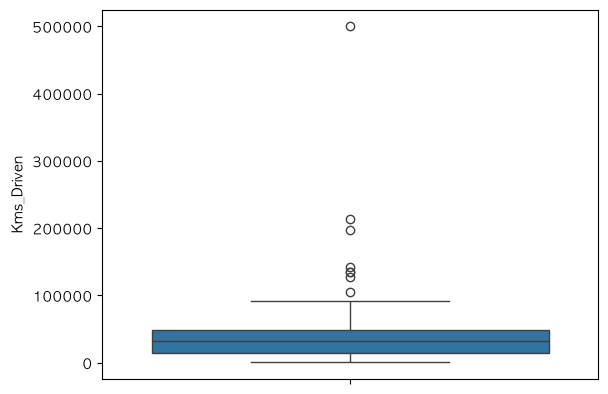

In [9]:
# "Kms_Driven"의 boxplot확인 
sns.boxplot(car_df, y= "Kms_Driven")
plt.show()

In [10]:
# 각 차량의 주행거리가 100000미만인지 검사 , 복사, 인덱스 재배치 
car_df = car_df[car_df["Kms_Driven"] < 100000].copy().reset_index(drop=True)
car_df


,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
289,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
290,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
291,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [11]:

car_df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,293.000000,293.000000,293.000000,293.000000,293.000000
mean,2013.791809,4.654710,7.445597,32652.122867,0.034130
std,2.690865,5.048855,8.462679,21435.638086,0.181873
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2015.000000,3.750000,6.100000,31427.000000,0.000000
75%,2016.000000,6.000000,9.540000,45780.000000,0.000000
max,2018.000000,35.000000,92.600000,92233.000000,1.000000


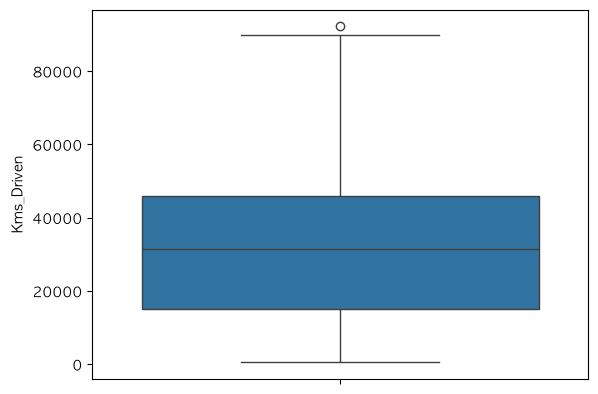

In [12]:
sns.boxplot(car_df, y= "Kms_Driven")
plt.show()

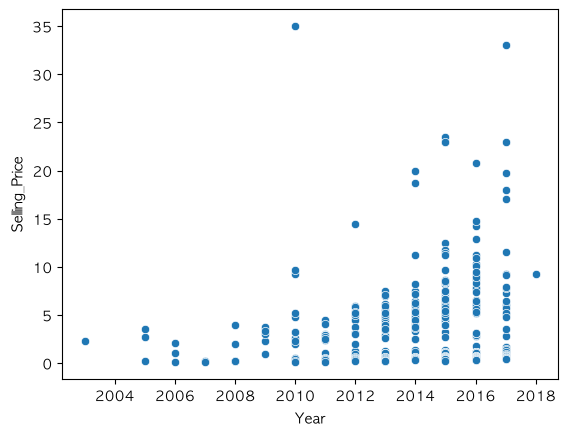

In [13]:
sns.scatterplot(car_df, x="Year", y= "Selling_Price")
plt.show()

In [14]:
# 2020년을 기준으로 파생변수 생성 
car_df["Vehicle_Age"] = 2020 - car_df["Year"]
# 출고연도보다 얼마나 오래 됬는 지 확인 

In [15]:
car_df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Vehicle_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,6
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,7
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,3
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,9
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,6


In [16]:
car_df["Fuel_Type"].value_counts()
# 각 연도 개수 세기 

Fuel_Type
Petrol    234
Diesel     57
CNG         2
Name: count, dtype: int64

In [17]:
car_df = car_df[car_df["Fuel_Type"]!="CNG"].copy()
car_df["Fuel_Type"].value_counts()
# "CGV"가 아닌 행 선택 , 복사 

Fuel_Type
Petrol    234
Diesel     57
Name: count, dtype: int64

In [18]:
# 원 핫 인코딩 : 분류형에서 수치형으로 변환 (get_dummies : 변환할때 쓰임)
car_df = pd.get_dummies(car_df, columns=["Fuel_Type", "Seller_Type", "Transmission"], drop_first=True, dtype= int)
# drop_first=True : 첫번째 카테고리 삭제 / dtype=int : 숫자형 자료형 지정 

In [19]:
# car_df.columns = columns
# car_df.head(3)
car_df

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,6,1,0,1
1,2013,4.75,9.54,43000,0,7,0,0,1
2,2017,7.25,9.85,6900,0,3,1,0,1
3,2011,2.85,4.15,5200,0,9,1,0,1
4,2014,4.60,6.87,42450,0,6,0,0,1
...,...,...,...,...,...,...,...,...,...
288,2016,9.50,11.60,33988,0,4,0,0,1
289,2015,4.00,5.90,60000,0,5,1,0,1
290,2009,3.35,11.00,87934,0,11,1,0,1
291,2017,11.50,12.50,9000,0,3,0,0,1


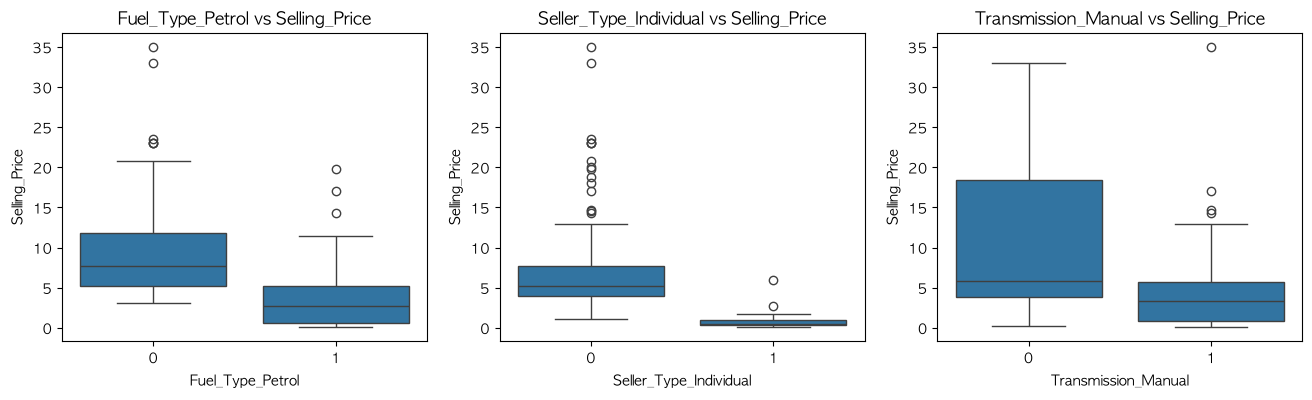

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# 개별그래프 : 1열 3행 

# ax=axes[0] : 첫번째 그래프
sns.boxplot(ax=axes[0], data=car_df, x="Fuel_Type_Petrol", y="Selling_Price")
axes[0].set_title("Fuel_Type_Petrol vs Selling_Price")

# ax=axes[1] : 두번째 그래프
sns.boxplot(ax=axes[1], data=car_df, x="Seller_Type_Individual", y="Selling_Price")
axes[1].set_title("Seller_Type_Individual vs Selling_Price")

# # ax=axes[2] : 세번째 그래프
sns.boxplot(ax=axes[2], data=car_df, x="Transmission_Manual", y="Selling_Price")
axes[2].set_title("Transmission_Manual vs Selling_Price")
plt.show()

In [21]:
# .corr() : 상관관계 계산하는 판다스 함수  
correlation_maxrix = car_df.corr()
correlation_maxrix

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
Year,1.000000,0.232067,-0.029342,-0.591753,-0.126058,-1.000000,-0.075838,-0.014822,-0.075008
Selling_Price,0.232067,1.000000,0.886872,0.123906,-0.100571,-0.232067,-0.541859,-0.568572,-0.372861
Present_Price,-0.029342,0.886872,1.000000,0.346668,-0.092067,0.029342,-0.459072,-0.542996,-0.316527
Kms_Driven,-0.591753,0.123906,0.346668,1.000000,-0.011859,0.591753,-0.293944,-0.355938,0.017111
Owner,-0.126058,-0.100571,-0.092067,-0.011859,1.000000,0.126058,0.045573,0.100228,0.069753
Vehicle_Age,-1.000000,-0.232067,0.029342,0.591753,0.126058,1.000000,0.075838,0.014822,0.075008
Fuel_Type_Petrol,-0.075838,-0.541859,-0.459072,-0.293944,0.045573,0.075838,1.000000,0.359843,0.083699
Seller_Type_Individual,-0.014822,-0.568572,-0.542996,-0.355938,0.100228,0.014822,0.359843,1.000000,0.092048
Transmission_Manual,-0.075008,-0.372861,-0.316527,0.017111,0.069753,0.075008,0.083699,0.092048,1.000000


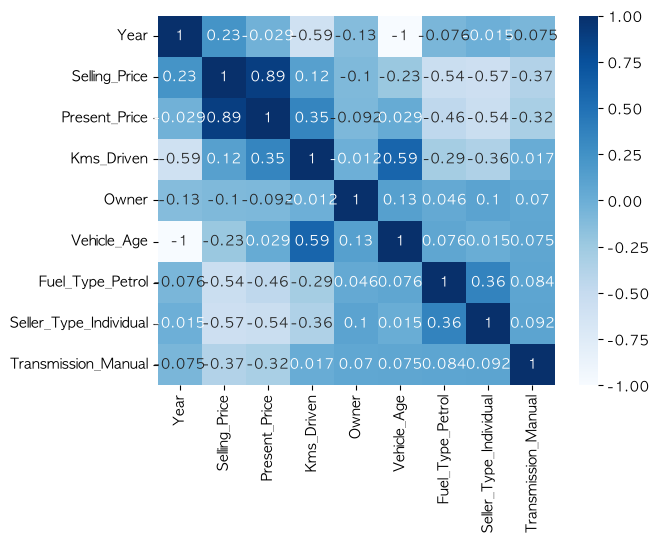

In [22]:
# annot=True : 히트맵 안에 숫자 적으라는 의미 
sns.heatmap(correlation_maxrix, cmap="Blues", annot=True)
plt.show()

In [23]:
# "Selling_Price" 지우기 
X = car_df.drop("Selling_Price", axis=1)
X.head()

,Year,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,2014,5.59,27000,0,6,1,0,1
1,2013,9.54,43000,0,7,0,0,1
2,2017,9.85,6900,0,3,1,0,1
3,2011,4.15,5200,0,9,1,0,1
4,2014,6.87,42450,0,6,0,0,1


In [24]:
y = car_df["Selling_Price"]
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [25]:
# inplace=True : 데이터 원본을 바꾸라는 의미
car_df.drop("Year", axis=1, inplace=True)
car_df.head(2)

,Selling_Price,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,6,1,0,1
1,4.75,9.54,43000,0,7,0,0,1


In [28]:
X= car_df.drop("Selling_Price", axis=1)
X.head(1)

,Present_Price,Kms_Driven,Owner,Vehicle_Age,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000,0,6,1,0,1


In [32]:
# VIF : X에 비슷한 데이터를 가지고 있는 지 확인  , .shape : 행과 열의 개수 알려줌-> shape[1]: 열은 몇개 있는지 확인 
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

[np.float64(1.8377356972000354),
 np.float64(2.197742883614677),
 np.float64(1.0359295875648615),
 np.float64(1.8531241130257097),
 np.float64(1.4057465858950131),
 np.float64(1.5781132261429054),
 np.float64(1.1453885376660138)]

## 트리
   - 계층적으로 자료를 표현할 때 적합한 자료구조
   - 데이터를 순차적으로 저장하지 않기 때문에 비선형 자료구조
   - 트리 내에 또 다른 트리가 있는 재귀적 자료구조
   - 하나의 루트 노드와 0개 이상의 하위 트리로 작성됨

### 트리의 사용 예시
   - 계층적 데이터 저장: 파일 및 폴더
   - 효율적인 검색속도: 효율적인 삽입, 삭제, 검색을 위해 사용
   - 데이터 베이스 인덱싱 구현
   - 힙(Heap)

### 트리 용어 정리 
   - 루트(Root)노드 : 트리의 가장 높은 곳에 있는 노드
   - 모든 노드는 루트노드의 서브트리에 속한다
   - 리프(Leaf)노드 : 트리의 가장 하단에 있는 노드
   - 자식노드가 없는 노드
   - 자식(Child)노드 : 동일한 부모를 가진 노드들을 의미함
   - 리프노드가 아닌 자식이 있는 노드 = 내부(Internal)노드, 비 단말(Non-Terminal)노드
   - 형제(Sibling)노드 : 동일한 부모를 가진 노드들을 의미한다
   - 조상(ancestro)노드 :  루트까지 경로상에 있는 모든 노드들의 집합
   - 후손(Descendant)노드 : 노드 아래로 매달린 모든 노드들의 집합
   - 서브트리(Subtree)노드 : 노드 자신과 후손 노드로 구성된 트리
   - 차수(Degree) : 어떤 노드가 가지고 있는 자식의 수
   - 레벨(Level) : 루트에서 얼마나 멀리 떨어져 있는지를 나타내는 것
   - 키(Key) : 탐색에 사용되는 노드에 저장된 정보

<img src="https://i.namu.wiki/i/8pViDtKiYxEmcz1zj2WHZEpLHeu4q4n1bAjOOTvA4rLde3d-miR4lbCeFRjhzuTV1SLW5vFdg81Q6vb6fm1I9Q.webp" style="width:800px;"/>

## 결정 트리(Decision Tree)란?
- 결정 트리는 데이터에 숨겨져 있는 규칙을 컴퓨터가 스스로 찾아내어, 마치 스무고개(IF-ELSE) 게임처럼 나무 가지를 뻗으며 정답을 찾아가는 지도학습(Supervised Learning) 알고리즘입니다.
- 한 줄 결론, 구간의 평균값으로 그 값을 예측하게 만든다.

| 구분 | 결정 트리 분류 (Classifier) | 결정 트리 회귀 (Regressor) |
| :--- | :--- | :--- |
| 목적 | 데이터가 어떤 그룹/카테고리에 속하는지 분류 | 데이터의 연속된 실숫값(수치)을 예측 |
| 예시 | 이 손님이 가방을 `산다(1)` / `안 산다(0)` | 오늘 특정 시간대에 따릉이가 `몇 대` 대여될까? |
| 최종 정답 결정 방식 | 다수결의 원칙<br>(마지막 방에 더 많은 쪽으로 분류) | 평균값 계산<br>(마지막 방에 모인 수치들의 평균을 내어 예측) |

### 2. 작동 원리 (데이터가 분리되는 과정)
1. 뿌리 노드 (Root Node): 전체 데이터가 시작되는 지점입니다.
2. 중간 노드 (Internal Node): 컴퓨터가 불순도를 낮추기 위해 최적의 질문(예: `Hour <= 17`)을 던져 데이터를 두 갈래로 쪼갭니다.
3. 최종 노드 (Leaf Node): 더 이상 쪼개지지 않는 마지막 나뭇잎 방입니다. 
   * 분류: 이 방에 모인 데이터 중 가장 많은 클래스가 최종 정답이 됩니다.
   * 회귀: 이 방에 모인 데이터들의 평균값이 최종 예측 숫자가 됩니다.

### 3. 장점과 단점
* 장점:
  * 시각화했을 때 컴퓨터가 왜 이런 판단을 내렸는지 사람이 눈으로 로직을 완벽히 이해할 수 있습니다. (설명 가능성 높음)
  * 데이터의 스케일링(정규화) 같은 전처리 작업의 영향을 거의 받지 않아 편리합니다.
* 단점:
  * 조건을 무한정 만들게 놔두면 훈련 데이터에만 완벽하게 맞아떨어지는 과적합(Overfitting)에 매우 취약합니다.
  * 해결책: 나무의 최대 깊이를 제한하는 가지치기(pruning) `max_depth` 같은 하이퍼파라미터 조율이 필수적입니다.

![](https://drive.google.com/thumbnail?id=1V1M-BXjutvDlwOhw6bUW-Zlh1J0etHpC&sz=w1000)

### 결정 트리 수행 순서
1. 최적의 특성(feature)과 분할 기준(threshold)을 찾아 첫 번째 분할을 수행
2. 만약 분류라면
   - Gini 불순도(Gini Impurity)
   - 엔트로피(Entropy)

4. 만약 회귀라면
   - 평균 제곱 오차(Mean Squared Error, MSE)
   - 절대 평균 오차(Mean Absolute Error

5. 각 하위 노드에 대해 위 단계를 반복하고 이 과정으로 여러 깊이로 설정합니다
6. 모든 노드가 더이상 나눌 수 없거나 특정 조건을 만족할 떄까지 반복합니다
7. 더 이상 분할이 불가능할 때 리프 노트가 생성됩니다
   - 분류 문제: 가장 많은 클래스가 있는 클래스를 예측값으로 사용
   - 회귀 문제: 평균값을 예측값으로 사용

#### Gini 불순도(Gini Impurity)
- 한 노드에 데이터 순수도(Purity)를 측정하는 지표입니다. 한 노드에 있는 샘플들이 동일한 클래스에 속할 확률이 높을수록 Gini 불순도가 낮아집니다
- 즉 노드가 얼마나 섞여있는지 나타내는 지표입니다.

#### 엔트로피(Entropy)
- 정보의 불확실성(혼란도)를 측정합니다. 엔트로피가 높을 수록 해당 노드에 데이터가 더 섞여있으며 예측하기 어렵습니다.
- 데이터가 균등하게 분포될 때 최대값을 가집니다.

### 예시 데이터프레임 (온도, 습도, 운동량)
- 아래 데이터가 있다고 가정해보자.

| 샘플 번호 | 온도 (°C) | 습도 (%) | 운동량 (Target, 분) |
| :---: | :---: | :---: | :---: |
| #1 | 15 | 40 | **60** |
| #2 | 18 | 45 | **55** |
| #3 | 28 | 75 | **20** |
| #4 | 30 | 80 | **15** |
| #5 | 32 | 85 | **10** |

### 1. 분산을 구한다
* **대상 데이터 (운동량):** `[60, 55, 20, 15, 10]` (총 5개)
* **평균 ($\mu$):** $(60 + 55 + 20 + 15 + 10) / 5 = \mathbf{32}$
* **분산 ($\sigma^2$):** 각 데이터에서 평균(32)을 뺀 뒤 제곱한 값들의 평균
  $$((60-32)^2 + (55-32)^2 + (20-32)^2 + (15-32)^2 + (10-32)^2) / 5$$
  $$= (784 + 529 + 144 + 289 + 484) / 5 = \mathbf{446}$$

- **처음 상태:** 운동량의 평균은 **32**, 분산(오차 위험도)은 **446**인 상태에서 출발합니다.

### 2. 운동량 평균 32에 해당하는 기준으로 중간 값후보에 등록한다.
예를 들어 습도를 골랐다면
* **#2 샘플:** 45%
* **#3 샘플:** 75%
- 45%와 75%의 딱 중간인 **60%** `(45 + 75) / 2` 가 칼날 후보가 된다.

- 왼쪽 그룹: 60보다 작은 그룹(40, 45)
- 오른쪽 그룹: 60보다 큰 그룹(75, 80, 85)

### 3. 왼쪽 그룹과 오른쪽 그룹 각각의 분산을 구한다
#### 1) 왼쪽 그룹 (습도 60% 미만: 40%, 45%)
* **대상 운동량:** `[60, 55]`
* **평균:** $(60 + 55) / 2 = \mathbf{57.5}$
* **분산 식:**
  $$\text{왼쪽 분산} = \frac{(60 - 57.5)^2 + (55 - 57.5)^2}{2}$$
  $$\text{왼쪽 분산} = \frac{(2.5)^2 + (-2.5)^2}{2} = \frac{6.25 + 6.25}{2} = \mathbf{6.25}$$

#### 2) 오른쪽 그룹 (습도 60% 이상: 75%, 80%, 85%)
* **대상 운동량:** `[20, 15, 10]`
* **평균:** $(20 + 15 + 10) / 3 = \mathbf{15}$
* **분산 식:**
  $$\text{오른쪽 분산} = \frac{(20 - 15)^2 + (15 - 15)^2 + (10 - 15)^2}{3}$$
  $$\text{오른쪽 분산} = \frac{(5)^2 + (0)^2 + (-5)^2}{3} = \frac{25 + 0 + 25}{3} = \frac{50}{3} \approx \mathbf{16.67}$$

* **가중 분산 합 공식:**
  $$\text{자식 노드 분산 합} = \left( \frac{\text{왼쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{왼쪽 분산} \right) + \left( \frac{\text{오른쪽 데이터 수}}{\text{전체 데이터 수}} \times \text{오른쪽 분산} \right)$$

* **실제 계산 식:**
  $$\text{자식 노드 분산 합} = \left( \frac{2}{5} \times 6.25 \right) + \left( \frac{3}{5} \times 16.67 \right)$$
  $$\text{자식 노드 분산 합} = 2.5 + 10 = \mathbf{12.5}$$

### 4. 최종 분산 감소량을 구한다

이제 처음에 구했던 부모 노드의 분산(446)에서 방금 구한 자식들의 분산 합(12.5)을 빼서 이 칼날(습도 60%)의 최종 점수를 매깁니다.

$$\text{분산 감소량} = \text{부모 분산} - \text{자식 분산 합}$$
$$\text{분산 감소량} = 446 - 12.5 = \mathbf{433.5}$$

### 5. 모든 컬럼의 값들을 계산하고 최종 분산 감소량이 가장 큰 값들만 선택하여 데이터가 1개가 될 때까지 나눈다.

In [33]:
y.head()

0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64

In [36]:
# test_size= 0.2 : 전체 데이터를 나눌 떄 20% 를 테스트용 데이터로 사용한다는 뜻 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(232, 7) (59, 7) (232,) (59,)


In [40]:
# 표준화 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
from sklearn.tree import DecisionTreeRegressor

In [44]:
# DecisionTreeRegressor : 연속된 숫자값을 예측하는 결정 트리 모델 
dtr = DecisionTreeRegressor(random_state=1016)

In [45]:
# .fit  : 데이터 전달 , 사용할 규칙,기준을 판단해서 저장 
dtr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",1016
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree wi

In [46]:
y_prad1 = dtr.predict(X_test_scaled)

In [47]:
print(y_prad1)

[ 5.25  6.25  1.1   5.25  1.15  0.3   0.45  4.5   4.75  2.65  7.45  0.25
  0.3   3.95  5.25  6.95  2.    6.25  8.4   0.12  7.9   0.45 11.25  2.55
  0.75  0.75  6.4   6.    0.4   0.65  0.15  4.75  0.48  8.25  1.15  2.9
  5.9   2.1   4.75  5.4   0.5   4.15  4.15  5.25  5.25  0.25  0.78  3.9
 12.9   1.1   2.7   5.5   0.78  4.75  4.95  0.38  0.6   8.4   4.75]


In [ ]:
# 주의 사항 
# 회귀는 예측 문제이므로 두개의 값이 일치하는지 아닌지 정확도를 평가하면 안된다

dtr.score(X_test, y_pred1)

### 회귀문제의 모델 평가
| 지표 | 수식 | 특징 | 장점 | 단점 |
| :---: | :---: | :--- | :--- | :--- |
| **MAE** | $\frac{1}{n}\sum\|y - \hat{y}\|$ | 절대값 오차의 평균 | 직관적이며, **이상치(Outlier)에 강인**함 | 느린 최적화, 미분이 불가능한 지점 존재 |
| **MSE** | $\frac{1}{n}\sum(y - \hat{y})^2$ | 제곱 오차의 평균 | 미분이 매끄러워 **가장 많이 사용**됨 | 오차가 클수록 제곱되어 **이상치에 민감**함 |
| **RMSE** | $\sqrt{\text{MSE}}$ | 제곱 오차 평균의 제곱근 | **원래 데이터와 단위가 일치**하여 직관적임 | 결국 MSE 기반이라 이상치의 영향을 받음 |₩

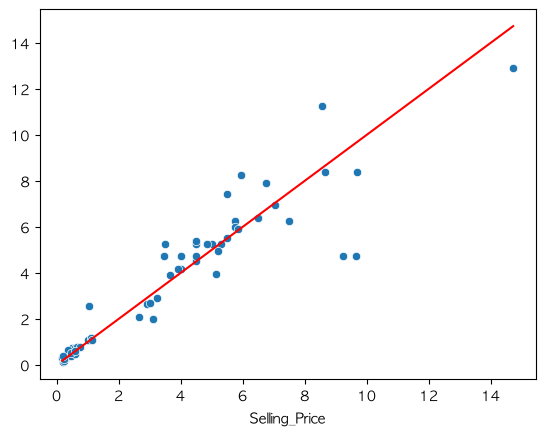

In [52]:
# 
sns.scatterplot(x=y_test, y=y_prad1)
                                # x축 , y축 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.show()

In [56]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error


In [57]:
# RMSE : 평균적으로 예측값이 실제값에서 얼마나 벗어났는지 계산 (숫자가 작을수록 오차가 적다는 의미 )
rmse = root_mean_squared_error(y_test, y_prad1)
print(f"RMSE: {rmse}")

RMSE: 1.1782937966341165


### 선형 모델 

In [58]:
from sklearn.linear_model import LinearRegression

In [59]:
# LinearRegression: 입력변수와 가격 사이의 관게를 직선 형태로 가정해서 예측하는 모델 (양수 계수: 값 커질수록 상승 , 음의 계수 : 값 커질수록 하락 )
lr = LinearRegression()

In [61]:
# lr 을 훈련시키는 코드 
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 4.11,-0.81, 0.03,...,-0.9 ,-0.74,-0.5 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.919
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](7,)","[23.15,18.71,15.03,...,12.15, 9.46, 7.55]"


In [65]:
y_prad2 = lr.predict(X_test_scaled)
y_prad2

array([ 4.61187633,  8.87616827, -0.4125723 ,  6.79632359,  1.20000392,
       -0.32403003, -0.78849016,  4.85194644,  3.91652607,  2.11196057,
        6.22941616,  0.05574463,  0.04460138,  5.56217552,  4.66784867,
        8.99113058,  2.67999757,  6.08049545,  8.00988568, -2.35503289,
        5.73815521, -0.56987319,  8.74363881, -0.27201414,  0.99398381,
        0.99638655,  7.67288602,  6.04677594,  1.66079481,  0.09603984,
       -1.2412441 ,  4.75903806,  0.49783695,  5.69713079,  1.52192145,
        4.71409725,  7.73263558,  3.44667454,  3.21421233,  5.59496688,
        0.24534036,  3.23924562,  5.07973979,  4.49185226,  4.9399641 ,
        0.69910229,  1.66990431,  4.36153492, 11.18418196,  0.81684943,
        3.14608675,  6.6945395 ,  1.55728179, 10.71672671,  5.82731871,
       -2.25803925,  1.08698662,  8.11913886, 11.04144744])

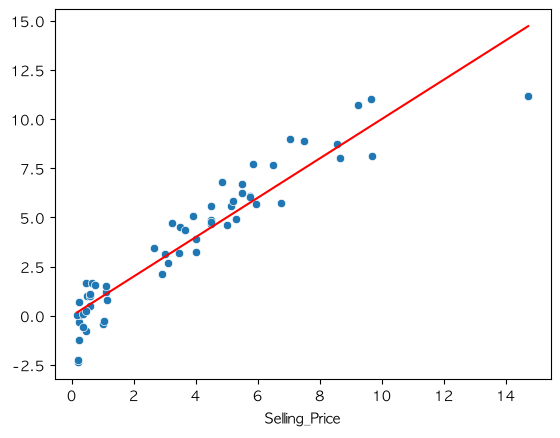

In [68]:
# X -> 예측을 참고하는 정보(재료) , y_test를 쓰는 이유는  예측을 확인하는 그래프이기 때문 
sns.scatterplot(x=y_test, y=y_prad2)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.show()

In [70]:
rmse2 = root_mean_squared_error(y_test, y_prad2)

In [71]:
"""
    결정트리 RMSE: 1.1793764511636315
    선형모델 RMSE: 1.1073053305563638
"""

None

In [72]:
dtr = DecisionTreeRegressor(max_depth=60, min_samples_leaf=40)


In [74]:
dtr = dtr.fit(X_train_scaled, y_train)

In [77]:
y_prad3 = dtr.predict(X_test_scaled)

In [78]:
rmse3 = root_mean_squared_error(y_test, y_prad3)

print(f"규제 적용(가지치기) RMSE: {rmse3}")

규제 적용(가지치기) RMSE: 2.098654106258555


In [81]:
from sklearn.tree import plot_tree
y_

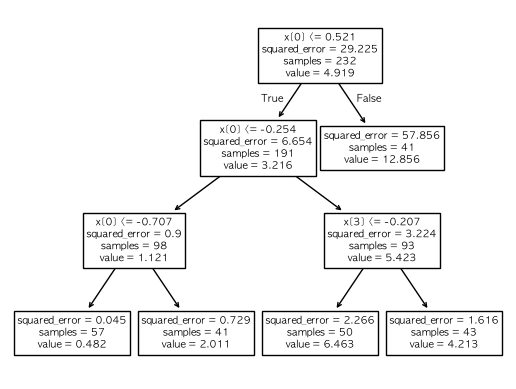

In [82]:
plot_tree(dtr)
plt.show()

# 랜덤 포레스트(RandomForestRegressor)
- "나무(결정 트리) 한 개는 과적합되기 쉬우니, 서로 다른 나무 100개를 만들어 그들의 예측값을 평균 내자!"
- 즉 결정트리의 상위 버전

## 핵심 하이퍼파라미터
* `n_estimators`: 숲에 심을 **나무의 개수** (기본값 100개, 많을수록 좋지만 무거워짐)
* `max_depth`, `min_samples_split` 등: 기존 결정 트리의 규제 파라미터와 완전히 동일하게 나무 각각에 적용됨`

In [83]:
from sklearn.ensemble import RandomForestRegressor

In [85]:
rf = RandomForestRegressor(random_state=2026)

In [89]:
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",2026
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease

In [90]:
y_prad4 = rf.predict(X_test)
y_prad4

array([ 5.5507,  7.1401,  1.0805,  5.1795,  1.1605,  0.2946,  0.496 ,
        4.6735,  4.3615,  2.7455,  6.997 ,  0.2897,  0.3552,  4.268 ,
        4.938 ,  7.2225,  2.9115,  5.6755,  9.0031,  0.1716,  6.559 ,
        0.5199, 11.178 ,  2.309 ,  0.5883,  0.6125,  6.646 ,  4.9065,
        0.4353,  0.4311,  0.2142,  5.294 ,  0.5638,  7.5745,  1.1895,
        2.5605,  6.6805,  2.937 ,  4.4615,  4.5665,  0.5311,  4.248 ,
        4.1895,  4.8145,  5.0435,  0.2117,  0.6848,  4.1135, 11.8221,
        1.126 ,  2.6565,  5.631 ,  0.6569,  8.0599,  5.014 ,  0.3646,
        0.6256,  9.5421,  8.0359])

In [91]:
rf.score(X_test, y_test)

0.9419886818123062

In [93]:
rmse = root_mean_squared_error(y_prad4, y_test)
print(f"랜덤 포레스트 RMSE: {rmse}")

랜덤 포레스트 RMSE: 0.7580658333067907


In [ ]:
# 각 features 중요도 

In [94]:
rf.feature_importances_

array([9.02019164e-01, 1.88637844e-02, 1.46866684e-05, 6.84673668e-02,
       3.25157255e-03, 4.00102696e-03, 3.38239849e-03])

In [97]:
# key : value 형식 
features_imp = pd.DataFrame({
    "Features": X_train.columns,
    "importances": rf.feature_importances_
}).sort_values(by="importances", ascending=False)
#  ascending=False 는  importances 열 기준으로 큰 값부터 내림차순 

features_imp

,Features,importances
0,Present_Price,0.902019
3,Vehicle_Age,0.068467
1,Kms_Driven,0.018864
5,Seller_Type_Individual,0.004001
6,Transmission_Manual,0.003382
4,Fuel_Type_Petrol,0.003252
2,Owner,0.000015


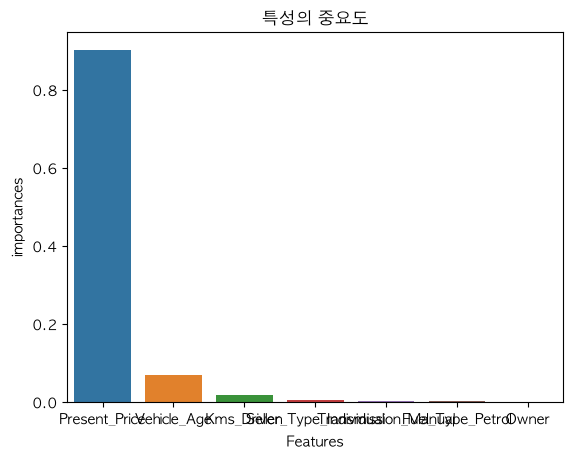

In [99]:
sns.barplot(features_imp, x= "Features", y="importances", hue="Features")
plt.title("특성의 중요도")
plt.show()